## Data Cleaning and Quality Assessment
## Homework 3 – Repurposing Data Sources
## Hadi Seyed

## 0. Setup

In [1]:
import os
import re
import requests
import subprocess
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from datetime import datetime

# Create a folder for our downloaded and extracted files
os.makedirs("data", exist_ok=True)

# User-Agent for the web requests
headers = {
    "User-Agent": "Mozilla/5.0"
}

print("Setup complete.")

Setup complete.


## 1. Extracting information from HTML documents 

### 1a. Download and parse the HTML documents

First, we download both Wikipedia articles using requests. Then save the original HTML files in data folder (locally), so the work is reproducible.

In [2]:
urls = {
    "United States": "https://en.wikipedia.org/wiki/COVID-19_vaccination_in_the_United_States",
    "Australia": "https://en.wikipedia.org/wiki/COVID-19_vaccination_in_Australia"
}

html = {}

for country, url in urls.items():
    response = requests.get(
        url,
        headers=headers,
        timeout=30
    )
    
    response.raise_for_status()
    
    html[country] = response.content
    
    filename = (
        "data/" +
        country.lower().replace(" ", "_") +
        "_vaccination.html"
    )
    
    with open(filename, "wb") as f:
        f.write(response.content)
    
    print(
        country,
        "downloaded successfully:",
        len(response.content),
        "bytes"
    )

print("\nRetrieved:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

United States downloaded successfully: 1254266 bytes
Australia downloaded successfully: 1268871 bytes

Retrieved: 2026-09-25 22:52:20


### 1b. Extract the vaccination tables

BeautifulSoup allows us to inspect the HTML structure and extract tables from the Wikipedia pages.

In [ ]:
# !pip install requests beautifulsoup4 pandas matplotlib

In [3]:
def extract_vaccination_tables(page_html):
    
    soup = BeautifulSoup(page_html, "html.parser")
    
    tables = []
    
    keywords = [
        "vaccinat",
        "dose",
        "population",
        "state",
        "territory",
        "eligible"
    ]
    
    for table_number, table in enumerate(
        soup.find_all("table")
    ):
        
        table_text = table.get_text(
            " ",
            strip=True
        ).lower()
        
        # Keep tables containing vaccination-related words
        if any(
            keyword in table_text
            for keyword in keywords
        ):
            
            rows = []
            
            for tr in table.find_all("tr"):
                
                cells = tr.find_all(
                    ["th", "td"]
                )
                
                values = [
                    cell.get_text(
                        " ",
                        strip=True
                    )
                    for cell in cells
                ]
                
                if values:
                    rows.append(values)
            
            if len(rows) >= 2:
                tables.append(
                    (table_number, rows)
                )
    
    return tables

In [4]:
html_tables = {}

for country, page in html.items():
    
    html_tables[country] = (
        extract_vaccination_tables(page)
    )
    
    print("\n====================")
    print(country)
    print("====================")
    
    print(
        "Candidate vaccination tables:",
        len(html_tables[country])
    )
    
    for table_number, rows in html_tables[country]:
        print(
            "Table:",
            table_number,
            "| Rows:",
            len(rows),
            "| Columns:",
            len(rows[0])
        )


United States
Candidate vaccination tables: 41
Table: 0 | Rows: 8 | Columns: 1
Table: 1 | Rows: 3 | Columns: 1
Table: 2 | Rows: 3 | Columns: 1
Table: 7 | Rows: 65 | Columns: 3
Table: 9 | Rows: 168 | Columns: 1
Table: 12 | Rows: 54 | Columns: 1
Table: 13 | Rows: 52 | Columns: 12
Table: 15 | Rows: 14 | Columns: 2
Table: 16 | Rows: 2 | Columns: 1
Table: 17 | Rows: 4 | Columns: 1
Table: 18 | Rows: 2 | Columns: 1
Table: 19 | Rows: 3 | Columns: 1
Table: 20 | Rows: 8 | Columns: 5
Table: 21 | Rows: 2 | Columns: 1
Table: 22 | Rows: 15 | Columns: 2
Table: 25 | Rows: 3 | Columns: 1
Table: 26 | Rows: 3 | Columns: 1
Table: 27 | Rows: 34 | Columns: 1
Table: 28 | Rows: 32 | Columns: 16
Table: 29 | Rows: 8 | Columns: 2
Table: 30 | Rows: 2 | Columns: 1
Table: 34 | Rows: 2 | Columns: 1
Table: 35 | Rows: 4 | Columns: 1
Table: 36 | Rows: 36 | Columns: 1
Table: 37 | Rows: 34 | Columns: 2
Table: 39 | Rows: 24 | Columns: 2
Table: 41 | Rows: 7 | Columns: 2
Table: 42 | Rows: 7 | Columns: 2
Table: 46 | Rows: 1

### Inspect the tables

In [5]:
for country, tables in html_tables.items():
    
    print("\n\n############################")
    print(country)
    print("############################")
    
    for table_number, rows in tables:
        
        print(
            "\nTable number:",
            table_number
        )
        
        for row in rows[:5]:
            print(row)



############################
United States
############################

Table number: 0
['Percent of the total population who are up to date with COVID-19 vaccines. Hover on the states on the map at the source page for exact numbers. Right-click on the source map, and then click "Show as a table" to get all the numbers. [ 1 ]']
['Date', 'December 14, 2020 – May 11, 2023 [ 2 ]']
['Location', 'United States Compact of Free Association : [ 3 ] [ 4 ] Palau Marshall Islands Micronesia']
['Cause', 'COVID-19 pandemic in the United States']
['Organized by', 'Centers for Disease Control and Prevention']

Table number: 1
['Percent of the total population of all ages by state or territory who completed the COVID-19 vaccination primary series. Booster doses are also recommended.']
['']
['See Commons source for changing sourcing info.']

Table number: 2
['Percentage with at least one vaccination dose']
['']
['US territories : GU = Guam AS = American Samoa MP = Northern Mariana Islands VI = Virgi

### 1c. Store the extracted content

The extracted HTML tables are converted into pandas DataFrames and saved as CSV files.

In [6]:
def rows_to_dataframe(rows):
    
    # Find the largest row length
    width = max(
        len(row)
        for row in rows
    )
    
    # Make every row the same length
    padded_rows = [
        row + [""] * (width - len(row))
        for row in rows
    ]
    
    # First row becomes the column names
    df = pd.DataFrame(
        padded_rows[1:],
        columns=padded_rows[0]
    )
    
    return df

In [7]:
html_dfs = {}

for country, tables in html_tables.items():
    
    html_dfs[country] = []
    
    prefix = (
        country.lower()
        .replace(" ", "_")
    )
    
    for n, (table_number, rows) in enumerate(tables):
        
        df = rows_to_dataframe(rows)
        
        filename = (
            f"data/{prefix}_html_table_{n}.csv"
        )
        
        df.to_csv(
            filename,
            index=False
        )
        
        html_dfs[country].append(df)
        
        print(
            country,
            "| Table",
            n,
            "| Shape:",
            df.shape,
            "| Saved:",
            filename
        )

United States | Table 0 | Shape: (7, 2) | Saved: data/united_states_html_table_0.csv
United States | Table 1 | Shape: (2, 1) | Saved: data/united_states_html_table_1.csv
United States | Table 2 | Shape: (2, 1) | Saved: data/united_states_html_table_2.csv
United States | Table 3 | Shape: (64, 3) | Saved: data/united_states_html_table_3.csv
United States | Table 4 | Shape: (167, 98) | Saved: data/united_states_html_table_4.csv
United States | Table 5 | Shape: (53, 96) | Saved: data/united_states_html_table_5.csv
United States | Table 6 | Shape: (51, 29) | Saved: data/united_states_html_table_6.csv
United States | Table 7 | Shape: (13, 8) | Saved: data/united_states_html_table_7.csv
United States | Table 8 | Shape: (1, 2) | Saved: data/united_states_html_table_8.csv
United States | Table 9 | Shape: (3, 5) | Saved: data/united_states_html_table_9.csv
United States | Table 10 | Shape: (1, 2) | Saved: data/united_states_html_table_10.csv
United States | Table 11 | Shape: (2, 2) | Saved: data

### 1d. Compare the extracted information

The following code displays the extracted tables so that the United States and Australia information can be compared.

In [8]:
for country, dataframes in html_dfs.items():
    
    print("\n==============================")
    print(country)
    print("==============================")
    
    for i, df in enumerate(dataframes):
        
        print(
            f"\nTable {i}"
        )
        
        display(
            df.head(10)
        )


United States

Table 0


,"Percent of the total population who are up to date with COVID-19 vaccines. Hover on the states on the map at the source page for exact numbers. Right-click on the source map, and then click ""Show as a table"" to get all the numbers. [ 1 ]",
0,Date,"December 14, 2020 – May 11, 2023 [ 2 ]"
1,Location,United States Compact of Free Association : [ ...
2,Cause,COVID-19 pandemic in the United States
3,Organized by,Centers for Disease Control and Prevention
4,Participants,"262,323,837 people have received at least one ..."
5,Outcome,79% of the United States population has receiv...
6,Website,CDC



Table 1


,Percent of the total population of all ages by state or territory who completed the COVID-19 vaccination primary series. Booster doses are also recommended.
0,
1,See Commons source for changing sourcing info.



Table 2


...

,v t e COVID-19 pandemic in Australia,,,,,
0,Clusters Statistics Timeline 2020 2021 January...,,,,,
1,Locations,States and territories Australian Capital Terr...,States and territories,Australian Capital Territory New South Wales N...,External territories,Christmas Island Cocos (Keeling) Islands Norfo...
2,States and territories,Australian Capital Territory New South Wales N...,,,,
3,External territories,Christmas Island Cocos (Keeling) Islands Norfo...,,,,
4,Government response,Biosecurity Act 2015 Coronavirus Australia COV...,,,,
5,Key people,Federal Greg Hunt Paul Kelly Scott Morrison → ...,Federal,Greg Hunt Paul Kelly Scott Morrison → Anthony ...,State,Daniel Andrews → Jacinta Allan Andrew Barr Gla...
6,Federal,Greg Hunt Paul Kelly Scott Morrison → Anthony ...,,,,
7,State,Daniel Andrews → Jacinta Allan Andrew Barr Gla...,,,,
8,Miscellaneous,Biosecurity in Australia COVID-19 protests Con...,,,,



Table 29


,States and territories,Australian Capital Territory New South Wales Northern Territory Queensland South Australia Tasmania Victoria Western Australia
0,External territories,Christmas Island Cocos (Keeling) Islands Norfo...



Table 30


,Federal,Greg Hunt Paul Kelly Scott Morrison → Anthony Albanese Brendan Murphy
0,State,Daniel Andrews → Jacinta Allan Andrew Barr Gla...


## 2. Extracting information from PDF documents

### 2a. Obtain the PDF versions

We download the PDF version of each Wikipedia article and save the files locally.

In [9]:
pdf_urls = {
    "United States":
        "https://en.wikipedia.org/api/rest_v1/page/pdf/COVID-19_vaccination_in_the_United_States",

    "Australia":
        "https://en.wikipedia.org/api/rest_v1/page/pdf/COVID-19_vaccination_in_Australia"
}

pdf_files = {}

for country, url in pdf_urls.items():
    
    filename = (
        "data/" +
        country.lower().replace(" ", "_") +
        "_vaccination.pdf"
    )
    
    response = requests.get(
        url,
        headers=headers,
        timeout=120
    )
    
    response.raise_for_status()
    
    with open(filename, "wb") as f:
        f.write(response.content)
    
    pdf_files[country] = filename
    
    print(
        country,
        "PDF downloaded:",
        filename
    )
    
    print(
        "Size:",
        len(response.content),
        "bytes"
    )

United States PDF downloaded: data/united_states_vaccination.pdf
Size: 2412446 bytes
Australia PDF downloaded: data/australia_vaccination.pdf
Size: 2542902 bytes


### 2b. Extract the tables from the PDFs

We use pdftotext with the -layout option. This attempts to preserve the spacing and column arrangement of the original PDF.

In [ ]:
# # pdftotext is not a Python package. It is a separate command-line program from Poppler.
# # Anaconda Prompt
# conda install -c conda-forge poppler

In [18]:
pdf_files = {
    "United States": "data/united_states_vaccination.pdf",
    "Australia": "data/australia_vaccination.pdf"
}

print(pdf_files)

{'United States': 'data/united_states_vaccination.pdf', 'Australia': 'data/australia_vaccination.pdf'}


In [19]:
import subprocess
import os

PDFTOTEXT = r"C:\Users\SEYEDS22\AppData\Local\miniconda3\Library\bin\pdftotext.exe"

def pdf_to_text(pdf_file):
    text_file = os.path.splitext(pdf_file)[0] + ".txt"

    subprocess.run(
        [PDFTOTEXT, "-layout", pdf_file, text_file],
        check=True
    )

    with open(text_file, "r", encoding="utf-8") as f:
        text = f.read()

    return text, text_file

In [20]:
pdf_text = {}

for country, pdf_file in pdf_files.items():

    text, text_file = pdf_to_text(pdf_file)

    pdf_text[country] = text

    print(country, "text extracted successfully.")
    print("Characters:", len(text))

United States text extracted successfully.
Characters: 114014
Australia text extracted successfully.
Characters: 166153


### Check the extracted PDF text

This is useful because you should inspect the PDF text before trying to automatically parse the table.

In [61]:
for country, text in pdf_text.items():
    
    print("\n==============================")
    print(country)
    print("==============================")
    
    # Show the first 100 lines
    lines = text.splitlines()
    
    for line in lines[:100]:
        if line.strip():
            print(line)


United States
COVID-19 vaccination in the United States
The COVID-19 vaccination campaign in the United
                                                           COVID-19 vaccination in the United
States was a mass immunization campaign for the
                                                                        States
COVID-19 pandemic in the United States. The Food
and Drug Administration (FDA) first granted
emergency use authorization to the Pfizer–BioNTech
vaccine on December 10, 2020,[8] and mass
vaccinations began four days later. The Moderna
vaccine was granted emergency use authorization on
December 17, 2020,[9] and the Janssen (Johnson &
Johnson) vaccine was granted emergency use
authorization on February 27, 2021.[10] It was not until
April 19, 2021, that all U.S. states had opened vaccine
eligibility to residents aged 16 and over.[11] On May
                                                            Percent of the total population who are up to
10, 2021, the FDA approv

### 2c. Convert the PDF extraction into structured data

PDF extraction is more difficult because the document stores visual layout rather than a true table structure, so the PDF does not give us a clean DataFrame automatically.

We first save the relevant table lines as raw text. Then we can inspect and clean the rows (split columns using repeated spaces).

In [24]:
import re

def split_pdf_row(line):
    
    # PDF tables often use several spaces between columns
    parts = re.split(
        r"\s{2,}",
        line.strip()
    )
    
    return [
        part.strip()
        for part in parts
        if part.strip()
    ]

In [25]:
for country, text in pdf_text.items():
    
    print("\n==============================")
    print(country)
    print("==============================")
    
    lines = text.splitlines()
    
    count = 0
    
    for line in lines:
        
        if (
            "vaccination" in line.lower()
            or "vaccinated" in line.lower()
            or "dose" in line.lower()
        ):
            
            print(
                split_pdf_row(line)
            )
            
            count += 1
            
            if count >= 20:
                break


United States
['COVID-19 vaccination in the United States']
['The COVID-19 vaccination campaign in the United']
['COVID-19 vaccination in the United']
['vaccinations began four days later. The Moderna']
['doses within his first hundred days in office, and', 'Marshall Islands']
['vaccination.[14][15][16] This goal was met on March 19,']
["By July 4, 2021, 67% of the United States' adult", 'received at least one dose']
['population had received at least one dose, just short of', 'administered of Pfizer–']
['states with below-average vaccination rates began to', '223,684,995 people have been']
['see increasing numbers of cases credited to the highly', 'fully vaccinated (both doses of']
['increased push by organizations and companies to', 'or one dose of Janssen)[5]']
['be vaccinated for COVID-19.', 'population has received at']
['least one dose of a vaccine']
['population is fully vaccinated']
['OSHA to mandate the vaccination of all federal branch']
['are not yet fully vaccinated for CO

### Save the raw PDF extraction

In [26]:
for country, text in pdf_text.items():
    
    filename = (
        "data/" +
        country.lower().replace(" ", "_") +
        "_pdf_extracted.txt"
    )
    
    with open(
        filename,
        "w",
        encoding="utf-8"
    ) as f:
        
        f.write(text)
    
    print(
        "Saved:",
        filename
    )

Saved: data/united_states_pdf_extracted.txt
Saved: data/australia_pdf_extracted.txt


### 2d. Compare PDF extraction with HTML

HTML and PDF contain similar information, but the extraction process is different.

HTML directly identifies rows and cells, while PDF extraction starts with text and spacing. Therefore, PDF data usually needs more cleaning and manual checking.

## 3. Analysis questions

Please read the PDF file.

## Extra credit: Visualization and insight generation

We'll make two visualizations:

1. Vaccination coverage comparison

2. Vaccination rollout timeline

#### 1. Vaccination coverage comparison

This visualization compares vaccination coverage values reported in the two articles.

The purpose is to provide a simple visual comparison of the reported vaccination percentages.

In [28]:
import pandas as pd

coverage = pd.DataFrame({
    "Country": [
        "United States",
        "United States",
        "Australia",
        "Australia"
    ],
    
    "Measure": [
        "At least one dose",
        "Fully vaccinated",
        "At least one dose",
        "Fully vaccinated"
    ],
    
    "Percent": [
        78.9,
        67.3,
        97.0,
        95.2
    ]
})

coverage

,Country,Measure,Percent
0,United States,At least one dose,78.9
1,United States,Fully vaccinated,67.3
2,Australia,At least one dose,97.0
3,Australia,Fully vaccinated,95.2


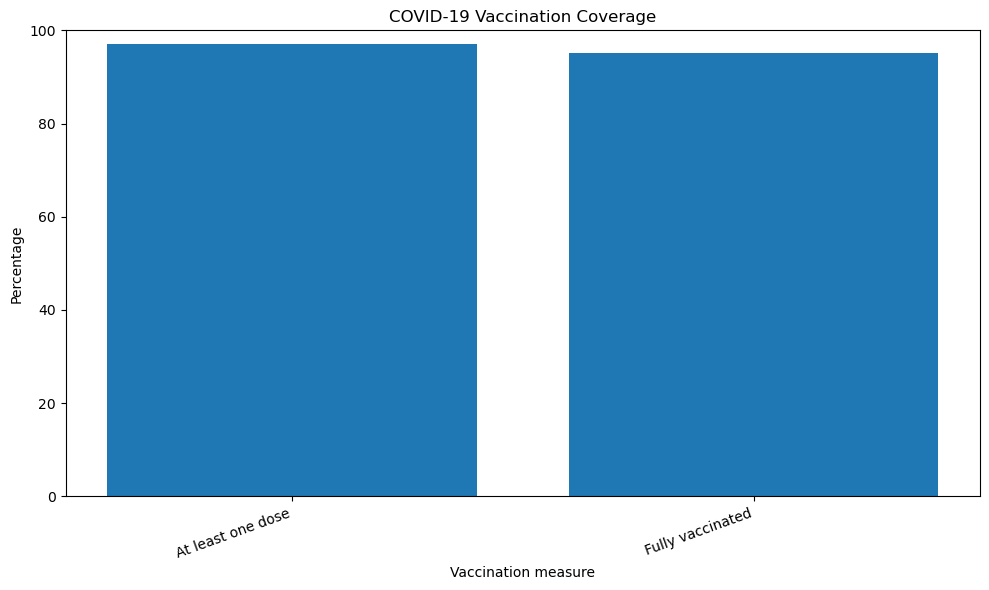

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    coverage["Measure"],
    coverage["Percent"]
)

plt.ylabel("Percentage")
plt.xlabel("Vaccination measure")

plt.title(
    "COVID-19 Vaccination Coverage"
)

plt.ylim(0, 100)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()

The chart summarizes vaccination coverage figures reported by the two articles. The percentages should be interpreted in the context of the dates and population definitions used by each article.

#### 2. Vaccination rollout timeline

The second visualization shows selected vaccination milestones for the United States and Australia.

A timeline is useful because it makes the sequence of the rollout easy to understand.

In [48]:
timeline = pd.DataFrame({
    
    "Date": pd.to_datetime([
        "2020-12-14",
        "2020-12-17",
        "2021-02-21",
        "2021-10-05"
    ]),
    
    "Country": [
        "United States",
        "United States",
        "Australia",
        "Australia"
    ],
    
    "Milestone": [
        "First vaccine doses administered",
        "Moderna authorization",
        "First public vaccination",
        "80% eligible population first dose"
    ]
})

timeline

,Date,Country,Milestone
0,2020-12-14,United States,First vaccine doses administered
1,2020-12-17,United States,Moderna authorization
2,2021-02-21,Australia,First public vaccination
3,2021-10-05,Australia,80% eligible population first dose


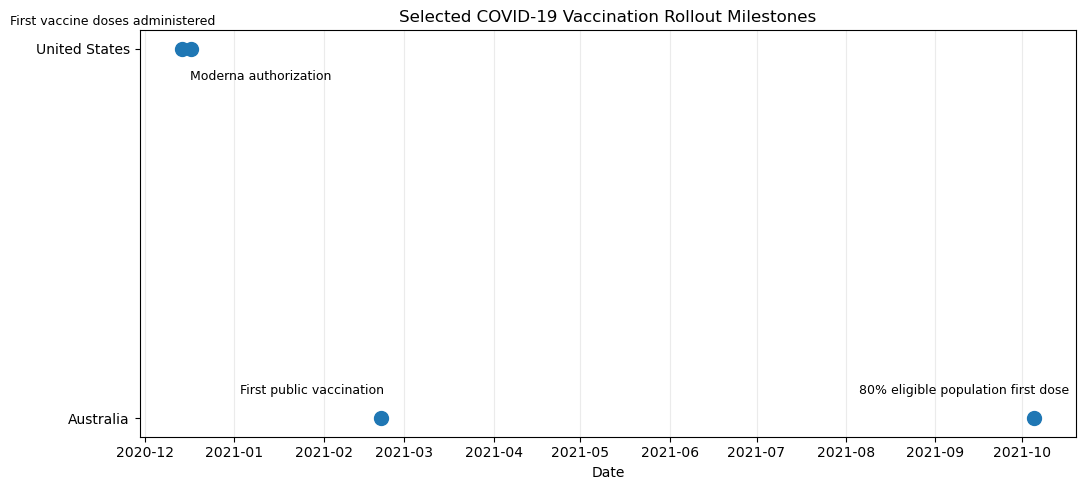

In [60]:
plt.figure(figsize=(11, 5))

y_values = []

for country in timeline["Country"]:
    
    if country == "United States":
        y_values.append(1)
    else:
        y_values.append(0)

plt.scatter(
    timeline["Date"],
    y_values,
    s=100
)

for x, y, label in zip(
    timeline["Date"],
    y_values,
    timeline["Milestone"]
):
    
    # plt.annotate(
    #     label,
    #     (x, y),
    #     xytext=(0, 10),
    #     textcoords="offset points",
    #     ha="center",
    #     fontsize=9
    # )

    # Put "Moderna authorization" below the dot
    if label == "Moderna authorization":
        offset = (50, -15)
        va = "top"
    
    # Keep "First vaccine doses administered" above the dot
    else:
        offset = (-50, 15)
        va = "bottom"
    
    plt.annotate(
        label,
        (x, y),
        xytext=offset,
        textcoords="offset points",
        ha="center",
        va=va,
        fontsize=9
    )
        
plt.yticks(
    [0, 1],
    ["Australia", "United States"]
)

plt.xlabel("Date")

plt.title(
    "Selected COVID-19 Vaccination Rollout Milestones"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()

plt.show()